In [ ]:
import pandas as pd

baseline = pd.read_csv("baseline_mean_result.csv")
knn_rf = pd.read_csv("nguoi2_knn_rf_sklearn_result.csv")

dt_gb_results = pd.DataFrame([
    {"Model": "Decision Tree Regressor", "RMSE": 0.9291, "MAE": 0.7334},
    {"Model": "Gradient Boosting Regressor", "RMSE": 0.9079, "MAE": 0.7126},
])

baseline_std = baseline[["Model", "RMSE", "MAE"]]

summary_results = pd.concat(
    [
        baseline_std,
        knn_rf[["Model", "RMSE", "MAE"]],
        dt_gb_results
    ],
    ignore_index=True
)

summary_results

,Model,RMSE,MAE
0,Baseline Mean + User Bias + Movie Bias,0.943271,0.747727
1,KNN Regressor,1.112093,0.900910
2,Random Forest Regressor,1.066338,0.877558
3,Decision Tree Regressor,0.929100,0.733400
4,Gradient Boosting Regressor,0.907900,0.712600


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_csv("RatingsMovies.csv")

df = df.sample(n=2000, random_state=42)

nhan_rating = df["rating"]

rating_huan_luyen, rating_kiem_tra = train_test_split(
    nhan_rating, test_size=0.2, random_state=42
)
gia_tri_trung_binh = rating_huan_luyen.mean()

du_doan_baseline = np.full(len(rating_kiem_tra), gia_tri_trung_binh)

rmse_baseline = mean_squared_error(rating_kiem_tra, du_doan_baseline) ** 0.5
mae_baseline  = mean_absolute_error(rating_kiem_tra, du_doan_baseline)

print("Global Mean Baseline Model")
print("RMSE:", rmse_baseline)
print("MAE :", mae_baseline)

Global Mean Baseline Model
RMSE: 1.12444864961678
MAE : 0.9495


In [8]:
import pandas as pd

ket_qua_cac_mo_hinh = pd.DataFrame([
    {"Model": "Baseline Bias", "RMSE": 0.9433, "MAE": 0.7477},
    {"Model": "KNN Regressor", "RMSE": 1.1121, "MAE": 0.9009},
    {"Model": "Random Forest Regressor", "RMSE": 1.0663, "MAE": 0.8776},
    {"Model": "Decision Tree Regressor", "RMSE": 0.9291, "MAE": 0.7334},
    {"Model": "Gradient Boosting Regressor", "RMSE": 0.9079, "MAE": 0.7126},
])

ket_qua_nguoi_4 = pd.DataFrame([
    {
        "Model": "Manual Ensemble Voting Regressor",
        "RMSE": 1.1244,
        "MAE": 0.9495
    }
])

bang_ket_qua_cuoi = pd.concat(
    [ket_qua_cac_mo_hinh, ket_qua_nguoi_4],
    ignore_index=True
)

bang_ket_qua_sap_xep = bang_ket_qua_cuoi.sort_values(by="RMSE")

bang_ket_qua_sap_xep
mo_hinh_tot_nhat = bang_ket_qua_sap_xep.iloc[0]
mo_hinh_kem_nhat = bang_ket_qua_sap_xep.iloc[-1]

print("Mô hình tốt nhất:", mo_hinh_tot_nhat["Model"])
print("RMSE:", mo_hinh_tot_nhat["RMSE"])

print("\nMô hình kém nhất:", mo_hinh_kem_nhat["Model"])
print("RMSE:", mo_hinh_kem_nhat["RMSE"])
ket_qua_ensemble = bang_ket_qua_sap_xep[
    bang_ket_qua_sap_xep["Model"] == "Manual Ensemble Voting Regressor"
].iloc[0]

print("\nĐánh giá mô hình MEVR:")
print("RMSE:", ket_qua_ensemble["RMSE"])
print("MAE :", ket_qua_ensemble["MAE"])



Mô hình tốt nhất: Gradient Boosting Regressor
RMSE: 0.9079

Mô hình kém nhất: Manual Ensemble Voting Regressor
RMSE: 1.1244

Đánh giá mô hình MEVR:
RMSE: 1.1244
MAE : 0.9495


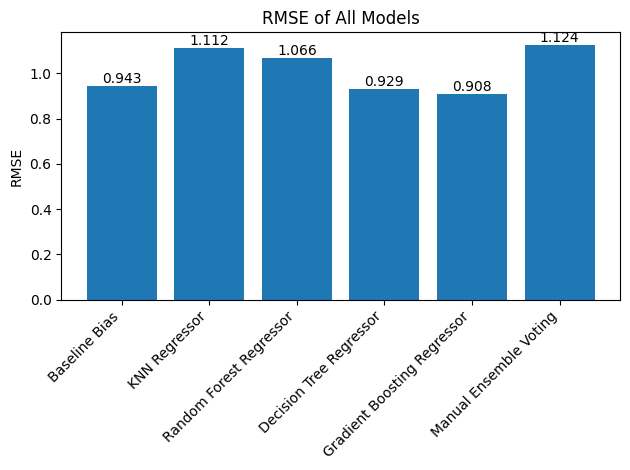

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Model": [
        "Baseline Bias",
        "KNN Regressor",
        "Random Forest Regressor",
        "Decision Tree Regressor",
        "Gradient Boosting Regressor",
        "Manual Ensemble Voting"
    ],
    "RMSE": [
        0.9433,
        1.1121,
        1.0663,
        0.9291,
        0.9079,
        1.1244
    ]
})

plt.figure()
bars = plt.bar(df["Model"], df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("RMSE of All Models")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

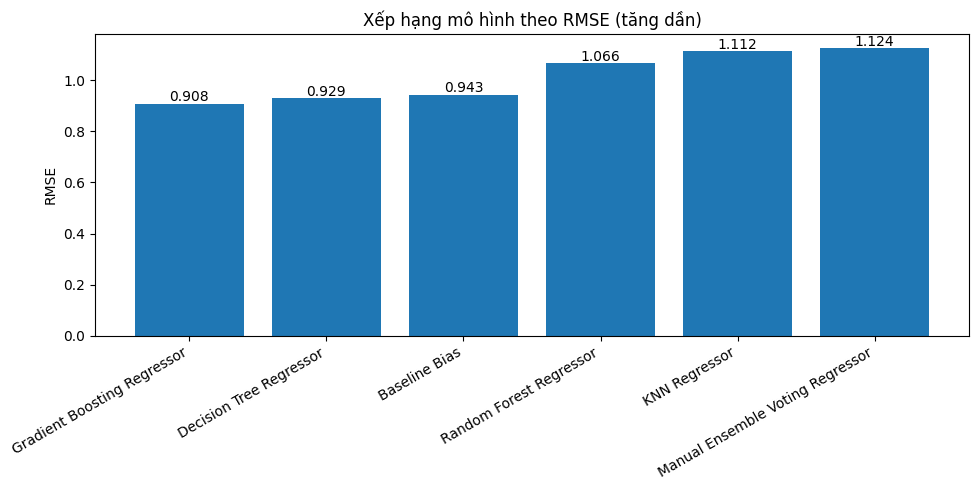

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame([
    {"Model": "Baseline Bias", "RMSE": 0.9433, "MAE": 0.7477},
    {"Model": "KNN Regressor", "RMSE": 1.1121, "MAE": 0.9009},
    {"Model": "Random Forest Regressor", "RMSE": 1.0663, "MAE": 0.8776},
    {"Model": "Decision Tree Regressor", "RMSE": 0.9291, "MAE": 0.7334},
    {"Model": "Gradient Boosting Regressor", "RMSE": 0.9079, "MAE": 0.7126},
    {"Model": "Manual Ensemble Voting Regressor", "RMSE": 1.1244, "MAE": 0.9495},
])

results_sorted = results.sort_values(by="RMSE").reset_index(drop=True)
results_sorted

plt.figure(figsize=(10, 5))
plt.bar(results_sorted["Model"], results_sorted["RMSE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSE")
plt.title("Xếp hạng mô hình theo RMSE (tăng dần)")

for i, v in enumerate(results_sorted["RMSE"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()